# 1. Оценка состава, объема и качества данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Размер данных:", df.shape)
df.head()

Размер данных: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Все колонки имеют тип float64, пропусков нет (8 non-null для каждой). Данные чистые.

In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Обратим внимание на диапазоны признаков, средние, стандартные отклонения. Например:

MedInc (медианный доход) от 0.5 до 15.0, среднее ~3.87.

HouseAge от 1 до 52, среднее ~28.6.

AveRooms (среднее число комнат) от 0.8 до 141, среднее ~5.4 (есть выбросы – максимальное 141 комната на домохозяйство).

AveBedrms от 0.3 до 34, среднее ~1.1.

Population от 3 до 35682, среднее ~1425.

AveOccup от 0.7 до 1243, среднее ~3.0.

MedHouseVal от 0.15 до 5.0, среднее ~2.07.

Вывод: Данные содержат выбросы по некоторым признакам (AveRooms, AveBedrms, Population, AveOccup). Целевая переменная ограничена сверху значением 5.0001.

# 2. Визуализация распределений признаков и целевой переменной

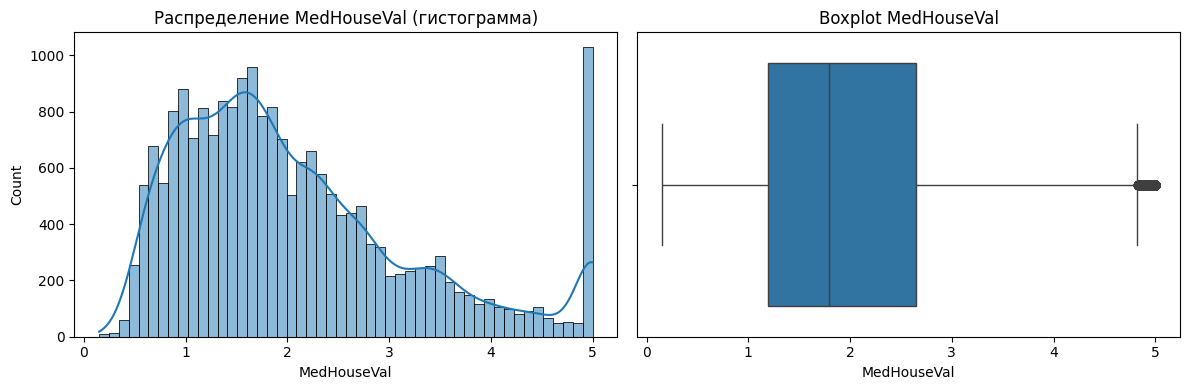

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['MedHouseVal'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Распределение MedHouseVal (гистограмма)')
sns.boxplot(x=df['MedHouseVal'], ax=axes[1])
axes[1].set_title('Boxplot MedHouseVal')
plt.tight_layout()
plt.show()

Наблюдения:

Распределение скошено влево, с пиком около 1.5–2.0.

Присутствует артефакт в виде резкого пика на значении 5.0 – это эффект каппинга (значения выше 5 были заменены на 5.0001).

Выбросы – все значения, близкие к 5, можно считать выбросами, но они реальны (дорогие дома).

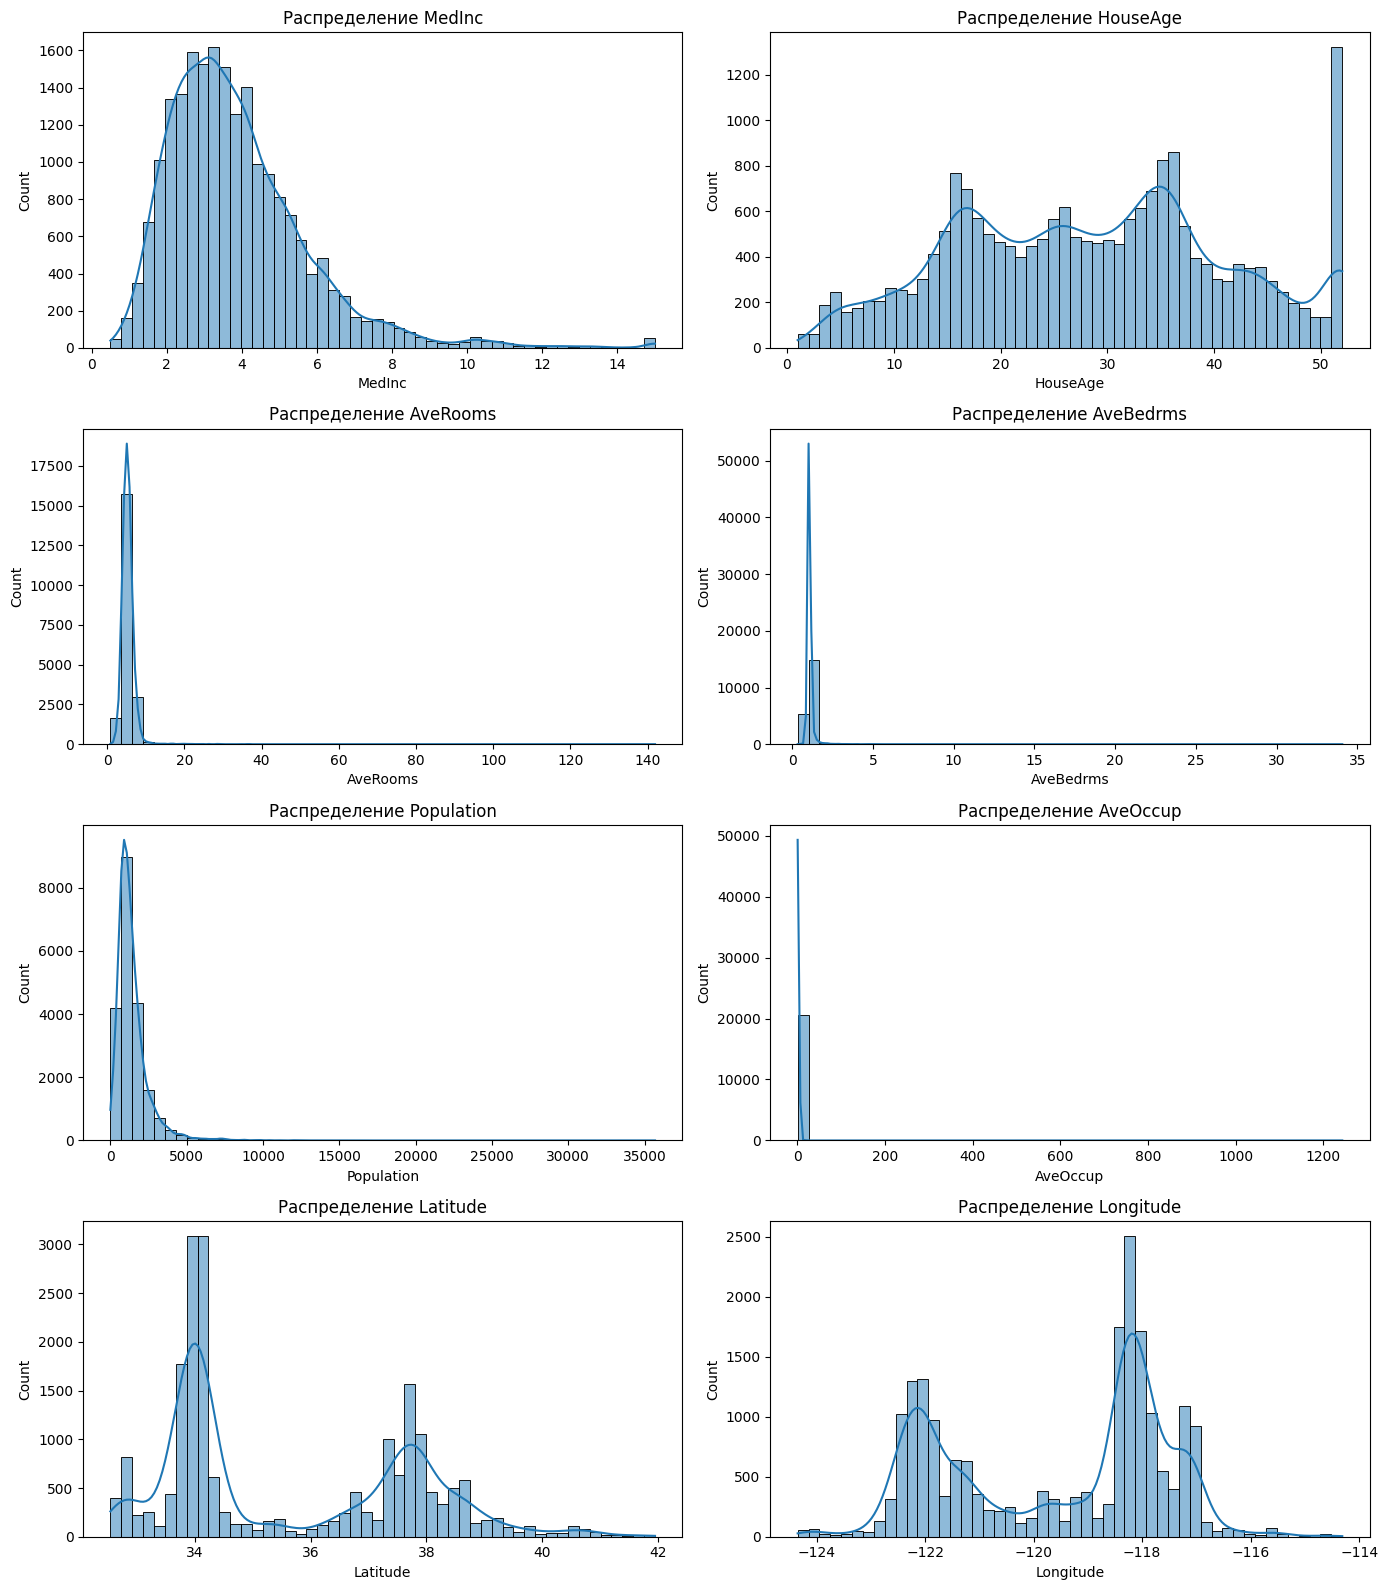

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
features = df.columns[:-1]
for i, col in enumerate(features):
    row, col_idx = divmod(i, 2)
    sns.histplot(df[col], bins=50, kde=True, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Распределение {col}')
plt.tight_layout()
plt.show()

MedInc, AveRooms, AveBedrms, Population, AveOccup имеют сильно скошенные распределения с длинными хвостами (выбросы).

HouseAge распределено более равномерно.

Latitude и Longitude имеют бимодальное распределение (соответствует географии Калифорнии – два основных кластера: побережье и центральная долина).

Выбросы особенно заметны в AveRooms (до 141), AveBedrms (до 34), Population (до 35682) и AveOccup (до 1243). Эти выбросы могут сильно влиять на линейные модели, но для бустинга менее критичны.

# 3. Корреляционный анализ

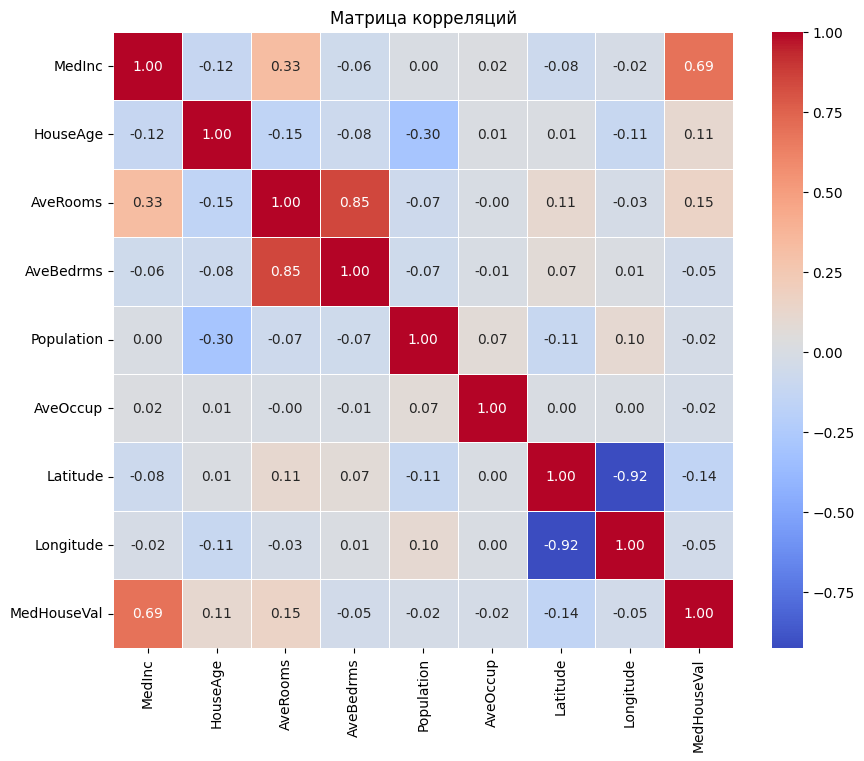

In [7]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляций')
plt.show()

Основные корреляции с целевой переменной MedHouseVal:

MedInc (0.69) – сильная положительная связь (чем выше доход, тем дороже жильё).

Latitude (-0.14) и Longitude (-0.05) – слабая отрицательная.

Остальные признаки имеют очень слабую корреляцию (< 0.1).

Межпризнаковые корреляции:

AveRooms и AveBedrms коррелируют (0.85) – логично, больше комнат – больше спален.

AveRooms и AveOccup (0.63) – больше комнат на человека.

AveBedrms и AveOccup (0.59).

Population и AveOccup (0.06) – практически нет связи.

Мультиколлинеарность между AveRooms и AveBedrms может быть проблемой для линейной регрессии; для бустинга это менее важно.

# 4. Анализ географических координат

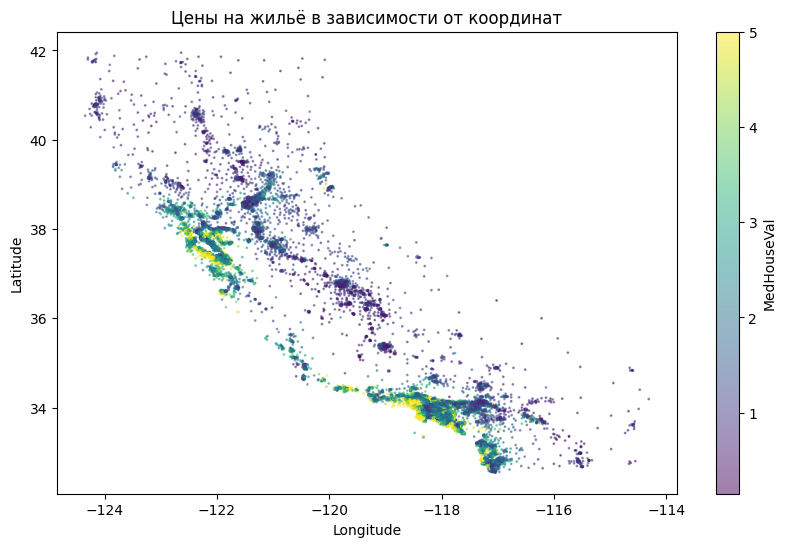

In [8]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Longitude'], df['Latitude'], c=df['MedHouseVal'], 
                      cmap='viridis', s=1, alpha=0.5)
plt.colorbar(scatter, label='MedHouseVal')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Цены на жильё в зависимости от координат')
plt.show()

Чётко видно побережье (слева, низкая долгота) – цены выше (жёлтые точки).

В центральной части (долина) цены ниже (фиолетовые).

Географическое положение – важный фактор, но в модели он уже учтён через координаты. Возможно, стоит создать признаки расстояния до океана или кластеризацию, но в рамках пилота оставим как есть.

# 5. Создание новых признаков (Feature Engineering)

В соответствии с дизайн документов создадим новые признаки:

In [9]:
df['rooms_per_household'] = df['AveRooms'] / df['AveOccup']
df['bedrooms_per_room'] = df['AveBedrms'] / df['AveRooms']

Проверим распределения новых признаков:

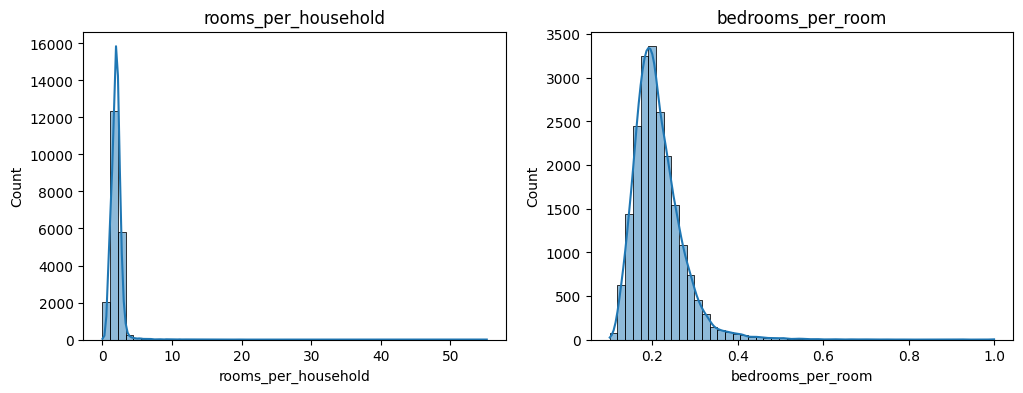

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['rooms_per_household'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('rooms_per_household')
sns.histplot(df['bedrooms_per_room'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('bedrooms_per_room')
plt.show()

##### rooms_per_household в основном сосредоточено около 2–4, есть выбросы (до 50).

bedrooms_per_room имеет пик около 0.2–0.3, что соответствует типичному дому (20–30% спален). Есть выбросы с аномально высокой долей спален (->1).

Эти признаки могут помочь модели уловить соотношения.

# 6. Выводы по EDA

## Состав данных: 20640 объектов, 8 исходных признаков, 1 целевая переменная. Пропусков нет.

## Качество данных: 
- Данные чистые, но содержат выбросы в признаках с большими значениями (AveRooms, AveBedrms, Population, AveOccup). Целевая переменная подвергнута каппингу сверху (максимум 5.0001).

## Ключевые зависимости:

- Наибольшее влияние на цену оказывает медианный доход (MedInc).

- Географическое положение также важно.

- Признаки количества комнат и спаней сильно коррелированы между собой.

## План предобработки:

- Для линейной регрессии потребуется стандартизация и, возможно, удаление сильно коррелированных признаков или использование Ridge-регрессии.

- Для градиентного бустинга стандартизация не обязательна, но можно оставить для единообразия.

- Выбросы можно оставить, так как бустинг устойчив к ним; для линейной модели рассмотрим робастную стандартизацию или удаление.

- Созданные признаки (rooms_per_household, bedrooms_per_room) включим в обучение.

## Риски:
- Линейная модель может показать низкое качество из-за нелинейностей и выбросов. Бустинг должен справиться лучше.